In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el dataset
RRHH = pd.read_csv(r'C:\Users\nuez_\Desktop\Proyecto\ProjecteData\Equip_24\Data\full_RRHH.csv')

In [3]:
RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Body_mass_index,Absenteeism_hours,Reason_Description
0,14,11,11,Monday,Spring,155,12,14,34,284.031,97,0,High School,2,True,False,0,25,120,Digestive system diseases
1,36,13,4,Wednesday,Winter,118,13,18,50,239.409,98,0,High School,1,True,False,0,31,120,Musculoskeletal/Connective tissue
2,9,6,7,Tuesday,Summer,228,14,16,58,264.604,93,0,High School,2,False,False,1,22,120,Nervous system diseases
3,28,9,7,Tuesday,Summer,225,26,9,28,230.290,92,0,High School,1,False,False,2,24,112,Circulatory system diseases
4,9,12,3,Tuesday,Autumm,228,14,16,58,222.196,99,0,High School,2,False,False,1,22,112,Skin/Subcutaneous diseases
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701,2,0,6,Monday,Winter,235,29,12,48,275.089,96,1,High School,1,False,True,5,33,0,Unknown/Other
702,21,0,6,Monday,Winter,268,11,8,33,275.089,96,1,Graduate,0,False,False,0,25,0,Unknown/Other
703,4,0,0,Tuesday,Summer,118,14,13,40,271.219,95,0,High School,1,True,False,8,34,0,Unknown/Other
704,8,0,0,Wednesday,Autumm,231,35,14,39,271.219,95,0,High School,2,True,False,2,35,0,Unknown/Other


In [4]:
RRHH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       706 non-null    int64  
 1   Reason_absence           706 non-null    int64  
 2   Month_absence            706 non-null    int64  
 3   Day_week                 706 non-null    object 
 4   Seasons                  706 non-null    object 
 5   Transportation_expense   706 non-null    int64  
 6   Distance_Residence_Work  706 non-null    int64  
 7   Service_time             706 non-null    int64  
 8   Age                      706 non-null    int64  
 9   Work_load_Average_day    706 non-null    float64
 10  Hit_target               706 non-null    int64  
 11  Disciplinary_failure     706 non-null    int64  
 12  Education                706 non-null    object 
 13  Son                      706 non-null    int64  
 14  Social_drinker           7

# BLOQUE 1 - VISIÓN GENERAL DEL AUSENTISMO


Total horas de ausentismo: 5043
Media de horas por ausencia: 7.14
Mediana de horas por ausencia: 3.00
Máximo de horas en una ausencia: 120
Mínimo de horas en una ausencia: 0


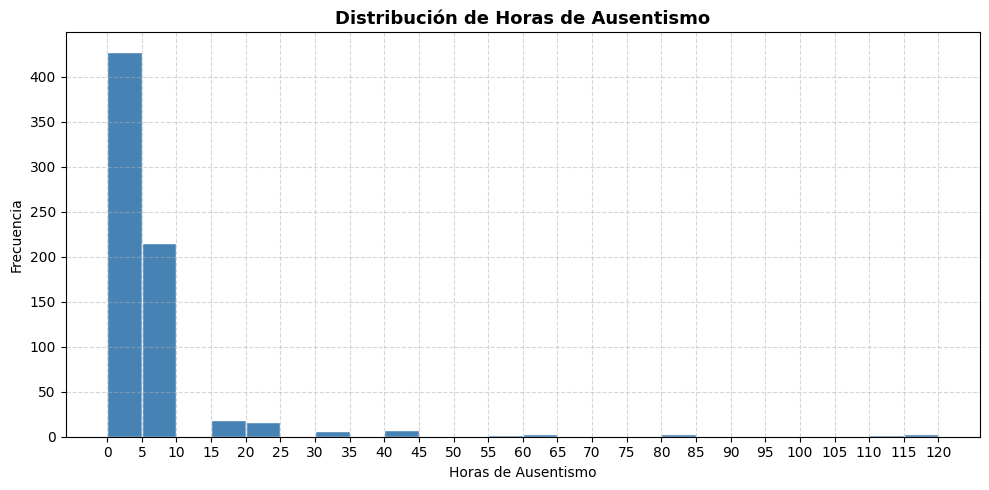

In [ ]:
# Magnitud general del ausentismo(histograma)
total_horas = RRHH['Absenteeism_hours'].sum()
media_horas = RRHH['Absenteeism_hours'].mean()
mediana_horas = RRHH['Absenteeism_hours'].median()
max_horas = RRHH['Absenteeism_hours'].max()
min_horas = RRHH['Absenteeism_hours'].min()

print(f"Total horas de ausentismo: {total_horas}")
print(f"Media de horas por ausencia: {media_horas:.2f}")
print(f"Mediana de horas por ausencia: {mediana_horas:.2f}")
print(f"Máximo de horas en una ausencia: {max_horas}")
print(f"Mínimo de horas en una ausencia: {min_horas}")

# Histograma de distribución con intervalos de 5 horas
plt.figure(figsize=(10, 5))
plt.hist(RRHH['Absenteeism_hours'], 
         bins=range(0, RRHH['Absenteeism_hours'].max() + 5, 5),
         color='steelblue', 
         edgecolor='white')
plt.title('Distribución de Horas de Ausentismo', fontsize=13, fontweight='bold')
plt.xlabel('Horas de Ausentismo')
plt.ylabel('Frecuencia')
plt.xticks(range(0, RRHH['Absenteeism_hours'].max() + 5, 5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Análisis de la Distribución:
* Concentración Principal: La gran mayoría de las ausencias son de corta duración, concentrándose más de 600 registros en el rango de 0 a 10 horas.
* Valores Atípicos (Outliers): Se identifican casos extremos que alcanzan hasta las 120 horas, lo que indica situaciones de bajas muy prolongadas.
* Impacto en Métricas: Debido a estos valores extremos, la media es considerablemente superior a la mediana (la cual se sitúa en torno a las 3 horas), elevando significativamente el promedio global de horas perdidas.
* Interpretación: El ausentismo está impulsado por una alta frecuencia de bajas breves (consultas médicas/dentales) y unos pocos casos críticos de larga duración que afectan la operatividad.

C:\Users\nuez_\AppData\Local\Temp\ipykernel_27128\2931886369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=RRHH, x='Absenteeism_hours', palette='Set2')


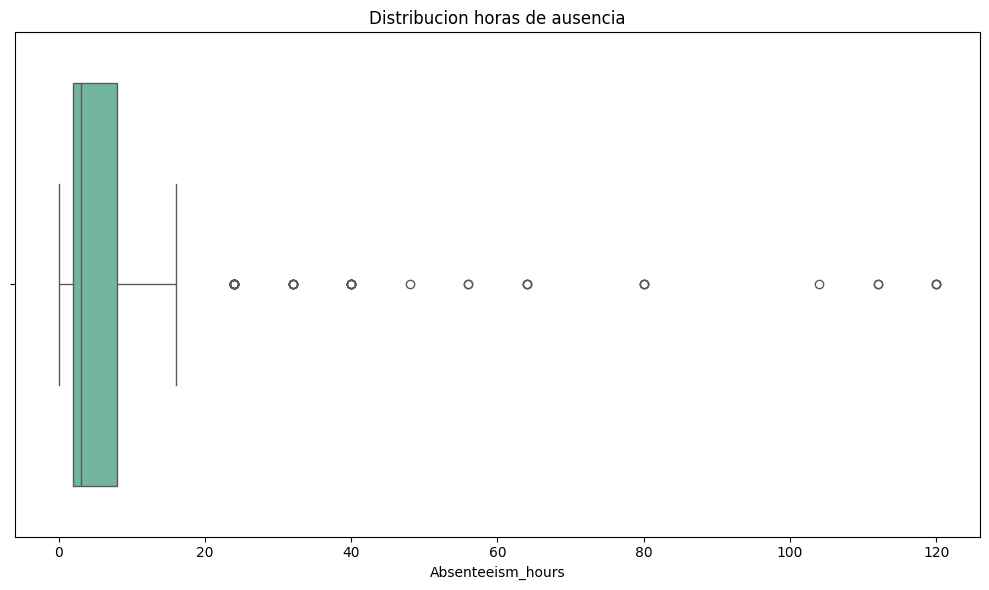

In [ ]:
#Boxplot distribución horas de ausencia
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(data=RRHH, x='Absenteeism_hours', palette='Set2')
plt.title('Distribucion horas de ausencia')
plt.tight_layout()
plt.show()

Análisis de Dispersión (Boxplot):
* Mediana vs. Media: La mediana se sitúa en torno a las 3 horas, lo que indica que el 50% de las ausencias son muy breves. No obstante, la media es considerablemente superior debido al efecto de los valores atípicos.
* Identificación de Outliers: Los puntos a la derecha del bigote representan valores atípicos (outliers) que van desde las 25 hasta las 120 horas.
* Impacto de Larga Duración: Estos valores extremos corresponden a bajas médicas de larga duración que, a pesar de ser poco frecuentes, tienen un impacto significativo en el total de horas perdidas por la empresa.
* Concentración de Datos: La caja principal confirma que la gran mayoría de los registros de ausentismo se concentran en un rango muy bajo, típicamente entre 0 y 10 horas.

C:\Users\nuez_\AppData\Local\Temp\ipykernel_27128\3201417393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=RRHH, x='Absenteeism_hours', palette='Set2',showfliers=False)


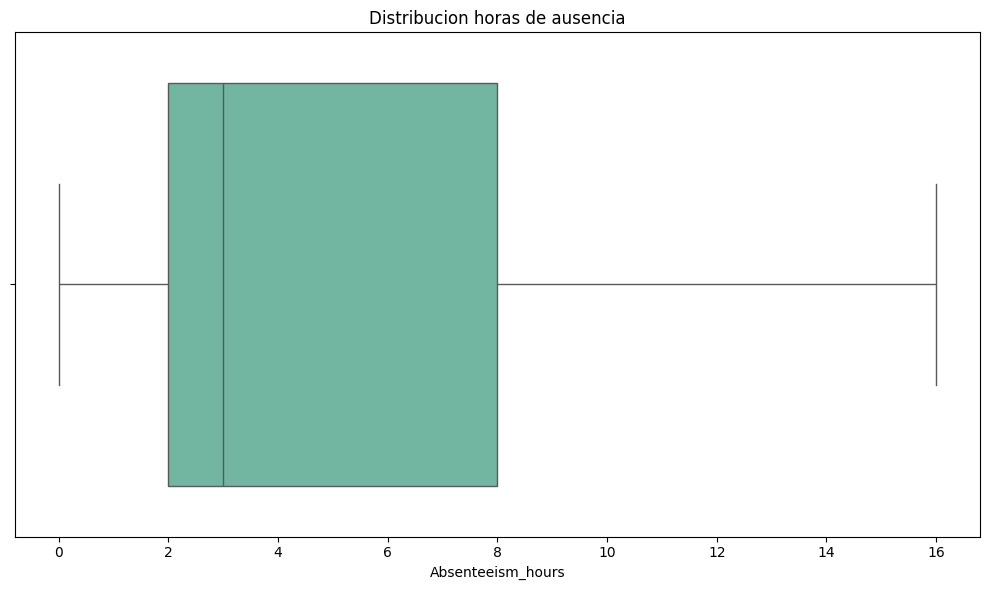

In [ ]:
#Boxplot sin outliers
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(data=RRHH, x='Absenteeism_hours', palette='Set2',showfliers=False)
plt.title('Distribucion horas de ausencia')
plt.tight_layout()
plt.show()

Análisis del Comportamiento Típico (Caja y Bigotes):
* Mediana Operativa: La línea central confirma que el 50% de las ausencias son de 3 horas o menos, lo que sugiere un predominio de salidas breves para trámites o consultas rápidas.
* Rango Intercuartílico (Caja): El grueso de los registros (el 50% central) se sitúa entre las 2 y las 8 horas de ausencia.
* Límite de Normalidad: Los "bigotes" del gráfico muestran que, dentro del comportamiento estándar (sin contar casos excepcionales), las bajas suelen extenderse hasta un máximo de 16 horas.
* Interpretación: Este gráfico permite ver con claridad la asimetría de los datos: la mayoría de la carga de ausentismo por frecuencia es de muy corta duración, concentrándose la mayor parte de los registros por debajo de las 10 horas

# BLOQUE 2 - VARIACIÓN TEMPORAL


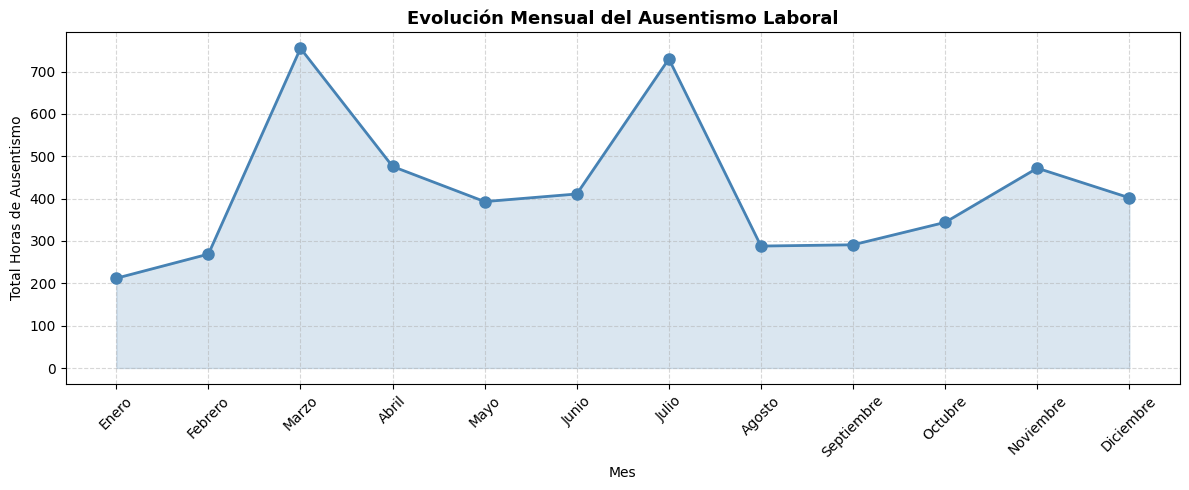

In [36]:
# Ausentismo por mes sin mes desconocido
ausentismo_mes = RRHH[RRHH['Month_absence'] != 0].groupby('Month_absence')['Absenteeism_hours'].sum()

month_labels = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 
                5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto', 9: 'Septiembre',
                10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
ausentismo_mes.index = ausentismo_mes.index.map(month_labels)

# Gráfico de línea temporal
plt.figure(figsize=(12, 5))
plt.plot(ausentismo_mes, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.fill_between(range(len(ausentismo_mes)), ausentismo_mes.values, alpha=0.2, color='steelblue')
plt.title('Evolución Mensual del Ausentismo Laboral', fontsize=13, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Total Horas de Ausentismo')
plt.xticks(range(len(ausentismo_mes)), ausentismo_mes.index, rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Análisis de la Evolución Mensual:
* Picos Máximos Identificados: Se observan dos incrementos críticos en la pérdida de horas: marzo (aprox. 750 horas) y julio (aprox. 730 horas).
* Causas Estacionales: El pico de marzo coincide con el final del verano brasileño (altas temperaturas y lluvias), lo que favorece enfermedades gastrointestinales, mientras que el de julio responde al invierno y al aumento de enfermedades respiratorias.
* Valles de Ausentismo: Los niveles más bajos se registran en agosto y septiembre (por debajo de las 300 horas), coincidiendo con periodos de mayor estabilidad meteorológica en Brasil.
* Acción Estratégica: Dada la predictibilidad de estos ciclos, se recomienda realizar refuerzos de plantilla o redistribución de tareas en febrero y junio para mitigar el impacto operativo de los meses pico.

Seasons
Winter    1479
Summer    1236
Spring    1221
Autumm    1107
Name: Absenteeism_hours, dtype: int64


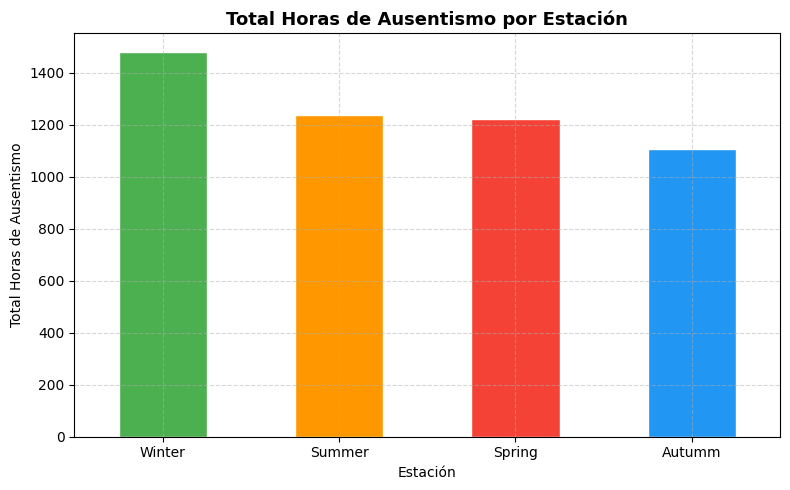

In [37]:
# Ausentismo por estación
ausentismo_season = RRHH.groupby('Seasons')['Absenteeism_hours'].sum().sort_values(ascending=False)

print(ausentismo_season)

# Gráfico de barras
plt.figure(figsize=(8, 5))
ausentismo_season.plot(kind='bar', 
                       color=['#4CAF50', '#FF9800', '#F44336', '#2196F3'],
                       edgecolor='white')
plt.title('Total Horas de Ausentismo por Estación', fontsize=13, fontweight='bold')
plt.xlabel('Estación')
plt.ylabel('Total Horas de Ausentismo')
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Análisis por Estación del Año:
* Estación Crítica: El invierno concentra el mayor volumen de ausencias con aproximadamente 1.470 horas, lo que se asocia directamente con el aumento de enfermedades respiratorias en el calendario brasileño.
* Distribución de Horas:
- Verano: 1.235 horas.
- Primavera: 1.215 horas.
- Otoño: 1.105 horas (la estación con menor impacto).
* Comportamiento General: Aunque el invierno presenta un pico moderado, la distribución de horas es relativamente uniforme entre el resto de las estaciones, manteniéndose siempre por encima de las 1.100 horas trimestrales.
* Interpretación: La diferencia entre la estación de mayor y menor ausentismo es de unas 365 horas, lo que refuerza la idea de que el ausentismo es un problema estructural persistente durante todo el año, más allá de los picos estacionales.

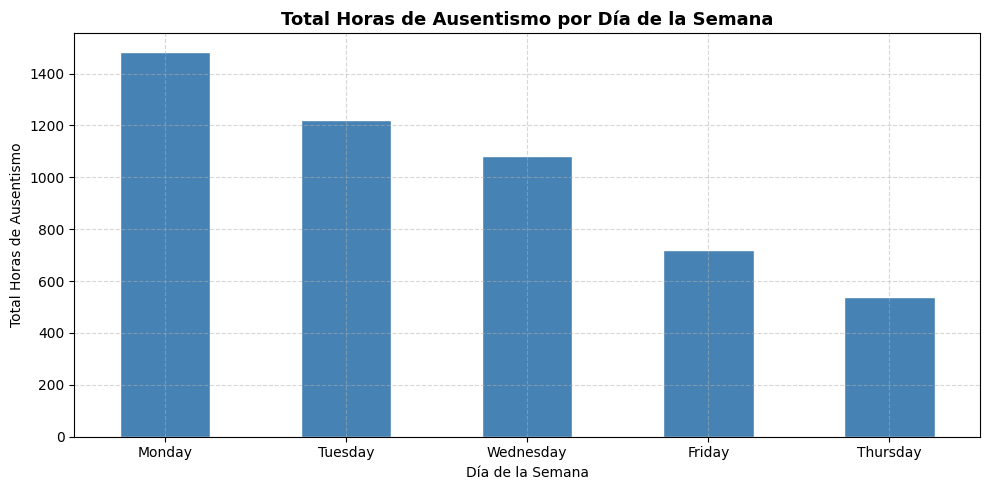


Número de registros de ausencia por día:
Day_week
Monday       158
Tuesday      150
Wednesday    144
Friday       135
Thursday     119
Name: Absenteeism_hours, dtype: int64


In [38]:
# Ausentismo por día de la semana
ausentismo_dia = RRHH.groupby('Day_week')['Absenteeism_hours'].sum().sort_values(ascending=False)

# Gráfico de barras
plt.figure(figsize=(10, 5))
ausentismo_dia.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Total Horas de Ausentismo por Día de la Semana', fontsize=13, fontweight='bold')
plt.xlabel('Día de la Semana')
plt.ylabel('Total Horas de Ausentismo')
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Ver también el número de ausencias por día (no solo horas)
print("\nNúmero de registros de ausencia por día:")
print(RRHH.groupby('Day_week')['Absenteeism_hours'].count().sort_values(ascending=False))

6. Horas de Ausentismo por Día de la Semana
* Lectura de Datos:
- Día de Máximo Impacto: El lunes (Monday) destaca significativamente con 1.470 horas y 158 registros.
- Día de Mínimo Impacto: El jueves (Thursday) es el día con menor nivel de ausentismo.
- Patrón Semanal: Se observa una reducción progresiva de horas de lunes a jueves, con un ligero incremento los viernes (Friday), donde se registran 720 horas.

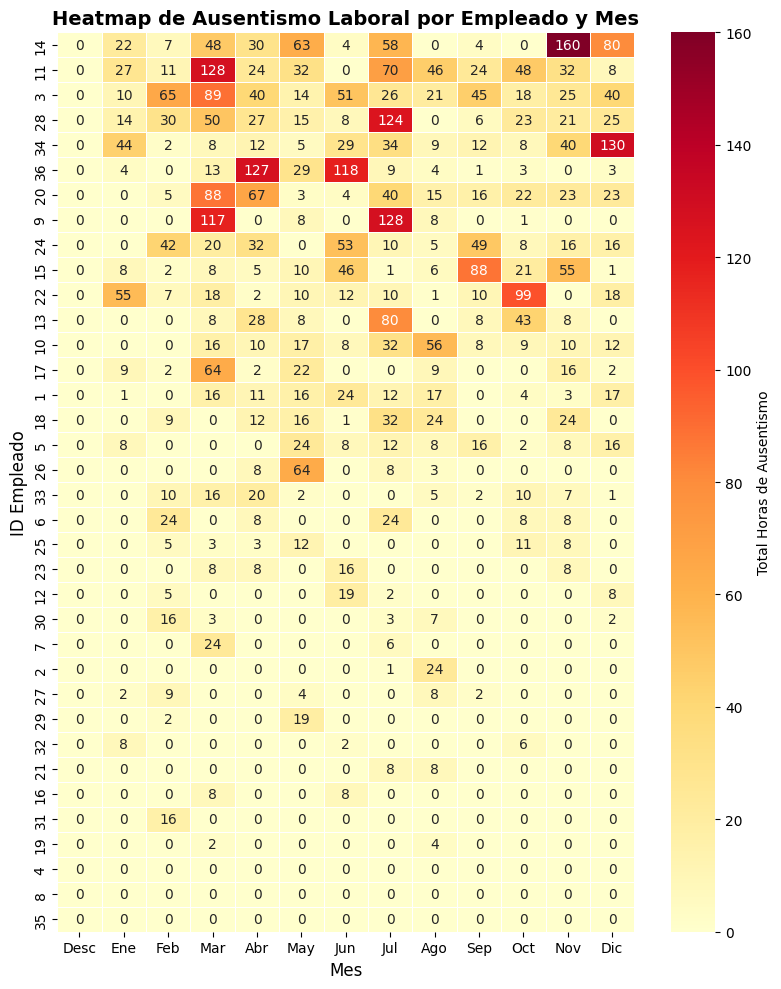

In [39]:
# Heatmap Ausentismo Laboral por empleado y mes 
import seaborn as sns

# Crear tabla pivote empleados x meses
heatmap_data = RRHH.pivot_table(
    index='ID', 
    columns='Month_absence', 
    values='Absenteeism_hours', 
    aggfunc='sum', 
    fill_value=0
)

# Renombrar columnas con nombres de meses
month_labels = {0: 'Desc', 1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 
                5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago', 9: 'Sep',
                10: 'Oct', 11: 'Nov', 12: 'Dic'}
heatmap_data.columns = heatmap_data.columns.map(month_labels)

# Ordenar empleados por total de horas descendente
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]

# Gráfico heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_data, 
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            annot=True,
            fmt='g',
            cbar_kws={'label': 'Total Horas de Ausentismo'})

plt.title('Heatmap de Ausentismo Laboral por Empleado y Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('ID Empleado', fontsize=12)
plt.tight_layout()
plt.show()

Análisis del Heatmap (Empleado por Mes):
* Distribución No Homogénea: Los picos de ausentismo mensuales no afectan a toda la plantilla por igual, sino que están impulsados por empleados concretos en momentos específicos del año.
* Focos Críticos Identificados (Máxima Intensidad):
- Empleado ID 14: Registra el punto más crítico de todo el dataset con 160 horas en noviembre.
- Empleado ID 34: Presenta un impacto significativo de 130 horas en diciembre.
- Empleado ID 11: Destaca con 128 horas acumuladas en marzo.
- Empleado ID 9: Registra un pico de 128 horas en julio.
- Empleado ID 28: Muestra focos importantes de 124 horas en julio y un volumen considerable en junio (127 horas) y marzo.
* Observación General: La mayoría de las celdas del gráfico presentan valores bajos o nulos (tonos claros), lo que confirma que el ausentismo de gran magnitud está altamente concentrado en un grupo reducido de empleados críticos.

# BLOQUE 3 - CAUSAS DEL AUSENTISMO

Reason_Description
Medical consultation                 142
Dental consultation                  108
Musculoskeletal/Connective tissue     55
Physiotherapy                         47
Unknown/Other                         43
Injury/Poisoning                      40
Patient follow-up                     37
Unjustified absence                   33
Laboratory examination                31
Digestive system diseases             26
Respiratory system diseases           25
Symptoms/Abnormal findings            21
Genitourinary system diseases         19
Infectious/Parasitic                  16
Eye/Adnexa diseases                   15
Nervous system diseases                8
Skin/Subcutaneous diseases             8
Ear/Mastoid diseases                   6
Factors influencing health status      6
Circulatory system diseases            4
Perinatal conditions                   3
Mental/Behavioural disorders           3
Blood donation                         3
Endocrine/Nutritional/Metabolic       

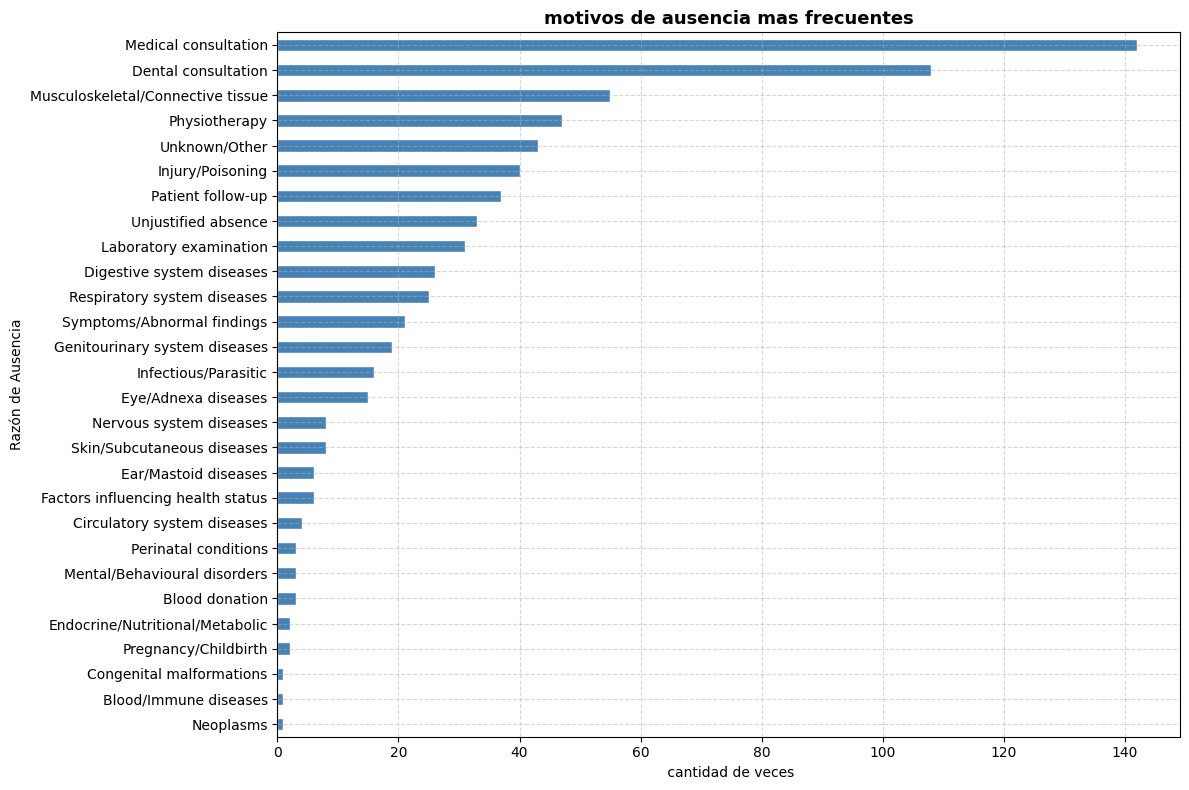

In [32]:
# Ausentismo por razón de ausencia
ausentismo_reason = RRHH.groupby('Reason_Description')['Absenteeism_hours'].count().sort_values(ascending=False)

print(ausentismo_reason)

# Gráfico de barras horizontal
plt.figure(figsize=(12, 8))
ausentismo_reason.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('motivos de ausencia mas frecuentes', fontsize=13, fontweight='bold')
plt.xlabel(' cantidad de veces')
plt.ylabel('Razón de Ausencia')
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Análisis de Causas del Ausentismo:
* Impacto por Horas Totales: Las enfermedades musculoesqueléticas y del tejido conectivo lideran ampliamente el ranking, seguidas por las lesiones e intoxicaciones.
* Dualidad Frecuencia vs. Duración: Aunque las consultas médicas y dentales son los motivos más comunes en número de registros, este gráfico demuestra que las patologías musculoesqueléticas generan bajas de mucha mayor duración, representando la mayor pérdida de horas acumuladas.
* Otras Causas Relevantes: Se observa un peso significativo de enfermedades del sistema digestivo y respiratorio, así como del seguimiento de pacientes.
* Ausentismo No Justificado: Aparece en una posición intermedia, lo que sugiere que, si bien existe, no es el factor principal de pérdida de tiempo en comparación con las causas médicas diagnosticadas.
* Conclusión Operativa: Los esfuerzos de prevención de salud laboral deben priorizar la ergonomía y la prevención de lesiones, ya que son estas las que más afectan la continuidad operativa por su larga duración.

Reason_Description
Musculoskeletal/Connective tissue    842
Injury/Poisoning                     729
Medical consultation                 408
Dental consultation                  329
Digestive system diseases            297
Patient follow-up                    285
Respiratory system diseases          276
Unjustified absence                  240
Symptoms/Abnormal findings           217
Skin/Subcutaneous diseases           187
Infectious/Parasitic                 182
Nervous system diseases              171
Circulatory system diseases          168
Genitourinary system diseases        167
Eye/Adnexa diseases                  150
Laboratory examination               108
Physiotherapy                        106
Factors influencing health status     35
Ear/Mastoid diseases                  32
Blood donation                        24
Neoplasms                             24
Mental/Behavioural disorders          19
Pregnancy/Childbirth                  16
Endocrine/Nutritional/Metabolic       

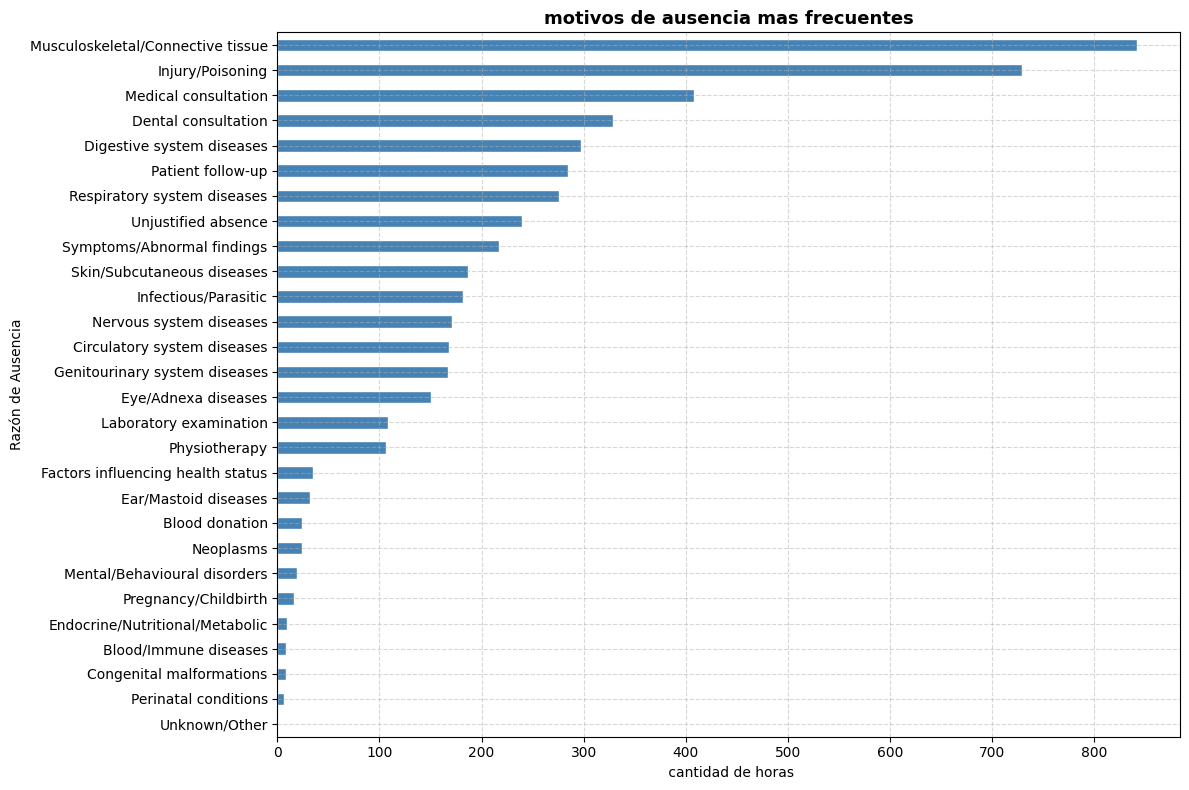

In [50]:
# Ausentismo por razón de ausencia
ausentismo_reason = RRHH.groupby('Reason_Description')['Absenteeism_hours'].sum().sort_values(ascending=False)

print(ausentismo_reason)

# Gráfico de barras horizontal
plt.figure(figsize=(12, 8))
ausentismo_reason.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('motivos de ausencia mas frecuentes', fontsize=13, fontweight='bold')
plt.xlabel(' cantidad de horas')
plt.ylabel('Razón de Ausencia')
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Análisis de los Motivos de Ausencia más Frecuentes:
* Liderazgo por Frecuencia: Las consultas médicas (Medical consultation) y las consultas dentales (Dental consultation) son, con diferencia, los motivos más recurrentes de ausencia en la empresa.
* Atención Programada: El hecho de que estas dos categorías lideren el ranking indica que una parte muy significativa del ausentismo corresponde a atención sanitaria programada.
* Patologías Relevantes: Tras las consultas, aparecen motivos de salud más específicos como las enfermedades musculoesqueléticas, la fisioterapia y las lesiones o intoxicaciones (Injury/Poisoning).
* Ausentismo No Justificado: La categoría de ausencia no justificada (Unjustified absence) se sitúa en una posición intermedia-alta, lo que indica que es un factor presente, aunque menos frecuente que las causas médicas.
* Diferencia Crítica entre Frecuencia e Impacto: Es importante notar que, aunque las consultas son las más frecuentes, las enfermedades musculoesqueléticas y las lesiones son las que realmente generan bajas de mayor duración y, por tanto, un mayor impacto operativo en horas totales.

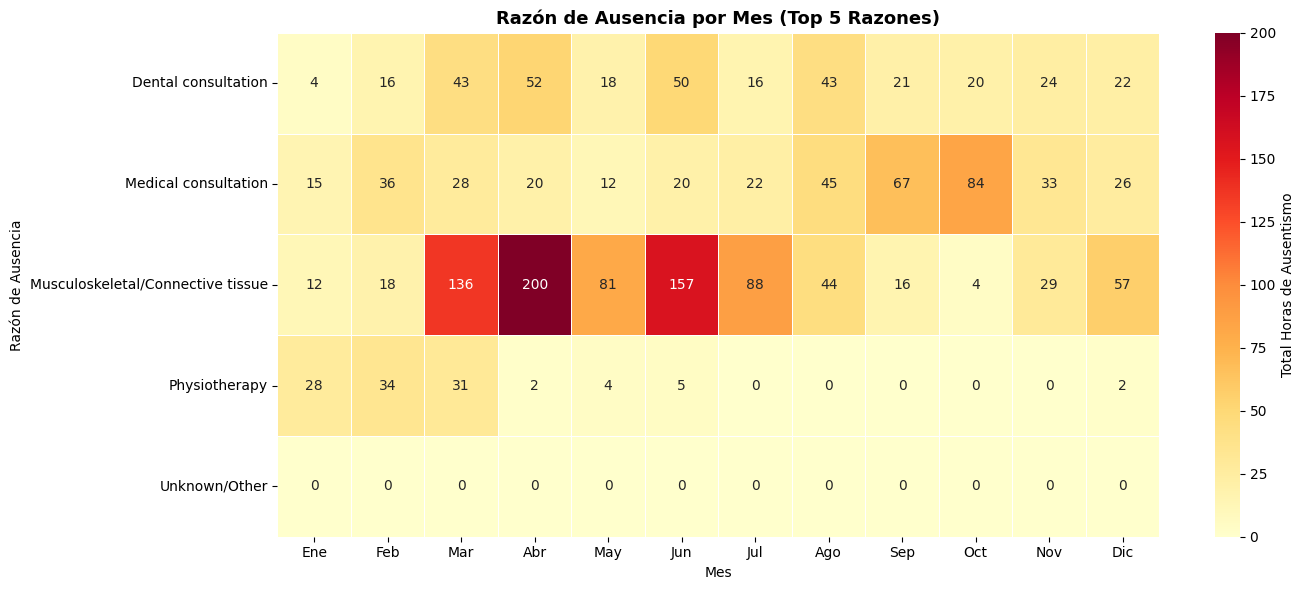

In [40]:
# Razón de ausencia por mes
ausentismo_razon_mes = RRHH[RRHH['Month_absence'] != 0].groupby(
    ['Month_absence', 'Reason_Description'])['Absenteeism_hours'].sum().reset_index()

# Quedarnos con el top 5 razones más frecuentes globalmente
top5_razones = RRHH['Reason_Description'].value_counts().head(5).index.tolist()
ausentismo_razon_mes = ausentismo_razon_mes[ausentismo_razon_mes['Reason_Description'].isin(top5_razones)]

# Pivot table
pivot = ausentismo_razon_mes.pivot_table(
    index='Reason_Description', 
    columns='Month_absence', 
    values='Absenteeism_hours', 
    fill_value=0
)

# Renombrar columnas con nombres de meses
month_labels = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 
                5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago', 
                9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}
pivot.columns = pivot.columns.map(month_labels)

# Heatmap
plt.figure(figsize=(14, 6))
import seaborn as sns
sns.heatmap(pivot, 
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            annot=True,
            fmt='g',
            cbar_kws={'label': 'Total Horas de Ausentismo'})

plt.title('Razón de Ausencia por Mes (Top 5 Razones)', fontsize=13, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Razón de Ausencia')
plt.tight_layout()
plt.show()

Análisis de la Estacionalidad por Causa (Top 5):
* Causa Dominante: Las enfermedades musculoesqueléticas y del tejido conectivo presentan los mayores impactos operativos, concentrándose drásticamente en marzo (136h), abril (200h) y junio (157h). Estas cifras coinciden con los periodos de mayor calor en Brasil, explicando gran parte del pico de ausentismo de esos meses.
* Consultas Médicas: Muestran una tendencia creciente hacia el final del año, alcanzando su mayor volumen en septiembre (67h) y octubre (84h).
* Consultas Dentales: Mantienen una presencia constante durante todo el año, con picos moderados en abril (52h) y junio (50h).
* Fisioterapia: Es una causa con fuerte estacionalidad al inicio del año, concentrándose específicamente en los meses de enero (28h), febrero (34h) y marzo (31h), desapareciendo casi por completo en el segundo semestre.
* Interpretación: El gráfico confirma que el ausentismo no es aleatorio; las patologías de larga duración (musculoesqueléticas) tienen ventanas temporales muy definidas que la empresa puede prever para su planificación de recursos.

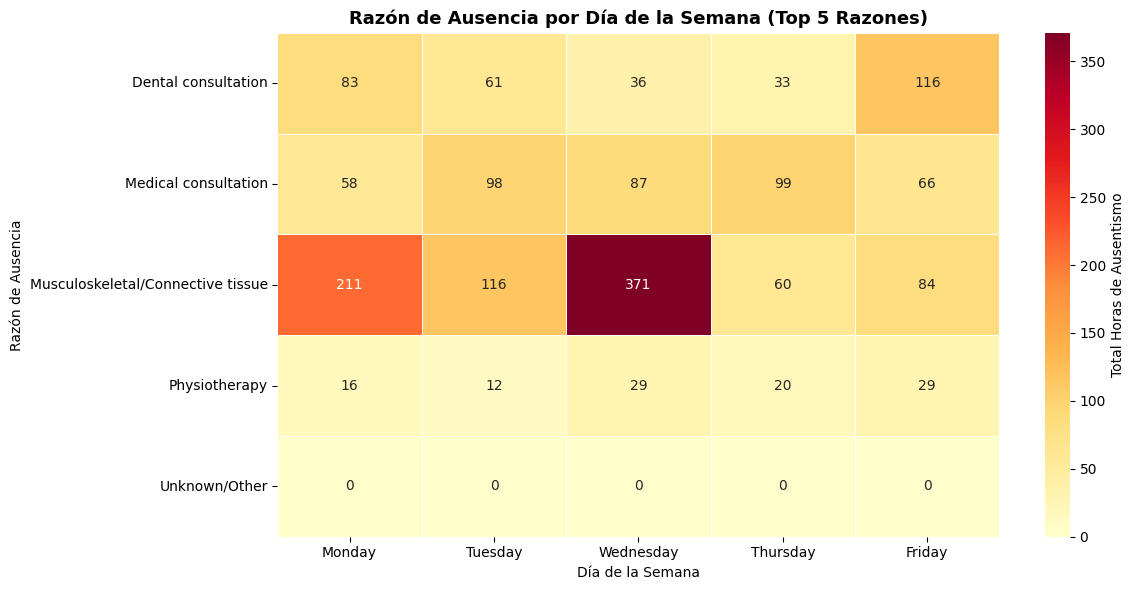


Detalle de razones de ausencia los LUNES:
Reason_Description
Dental consultation                  22
Medical consultation                 21
Musculoskeletal/Connective tissue    12
Injury/Poisoning                     11
Digestive system diseases            10
Laboratory examination               10
Unjustified absence                  10
Patient follow-up                     9
Respiratory system diseases           9
Physiotherapy                         8
Eye/Adnexa diseases                   7
Unknown/Other                         6
Infectious/Parasitic                  6
Symptoms/Abnormal findings            5
Genitourinary system diseases         3
Nervous system diseases               2
Skin/Subcutaneous diseases            2
Circulatory system diseases           1
Factors influencing health status     1
Pregnancy/Childbirth                  1
Blood donation                        1
Ear/Mastoid diseases                  1
Name: count, dtype: int64


In [41]:
# Razón de ausencia por día de la semana
ausentismo_razon_dia = RRHH.groupby(
    ['Day_week', 'Reason_Description'])['Absenteeism_hours'].sum().reset_index()

# Top 5 razones más frecuentes
ausentismo_razon_dia = ausentismo_razon_dia[ausentismo_razon_dia['Reason_Description'].isin(top5_razones)]

# Pivot table
pivot_dia = ausentismo_razon_dia.pivot_table(
    index='Reason_Description',
    columns='Day_week',
    values='Absenteeism_hours',
    fill_value=0
)

# Ordenar días de la semana
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
pivot_dia = pivot_dia.reindex(columns=orden_dias)

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_dia,
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            annot=True,
            fmt='g',
            cbar_kws={'label': 'Total Horas de Ausentismo'})

plt.title('Razón de Ausencia por Día de la Semana (Top 5 Razones)', fontsize=13, fontweight='bold')
plt.xlabel('Día de la Semana')
plt.ylabel('Razón de Ausencia')
plt.tight_layout()
plt.show()

# Análisis específico del lunes
print("\nDetalle de razones de ausencia los LUNES:")
lunes = RRHH[RRHH['Day_week'] == 'Monday']['Reason_Description'].value_counts()
print(lunes)

Análisis de Causas por Día de la Semana (Top 5):
* Desmitificación del Lunes: Aunque el lunes es el día con más horas perdidas en total, la causa principal de larga duración (enfermedades musculoesqueléticas) alcanza su máximo impacto los miércoles con 371 horas. Esto confirma que las bajas más severas responden a causas médicas reales y no a un patrón de ausentismo injustificado para alargar el descanso.
* Patrón de Consultas Dentales: Es el único motivo que muestra un pico claro al final de la semana, acumulando 116 horas los viernes. Este comportamiento sí podría estar asociado a una programación de citas que busca extender el tiempo de descanso semanal.
* Distribución de Consultas Médicas: Presentan una frecuencia más equilibrada durante toda la semana, con ligeros repuntes los martes (98h) y jueves (99h).
* Fisioterapia: Mantiene niveles bajos y constantes, con un pequeño incremento hacia la mitad y el final de la semana (29h los miércoles y viernes).
* Conclusión Operativa: Los datos sugieren que el volumen de horas del lunes está compuesto por muchas ausencias de diversas causas, pero la gravedad clínica (medida en horas por registro) se desplaza hacia la mitad de la semana laboral.

# BLOQUE 4 - FACTORES DE RIESGO

     Total Horas  Media Horas  Num Ausencias
Son                                         
0           1540     5.724907            269
1           1365     6.093750            224
2           1649    10.570513            156
3            183    12.200000             15
4            306     7.285714             42

Distribución por número de hijos:
Son
0    269
1    224
2    156
3     15
4     42
Name: count, dtype: int64


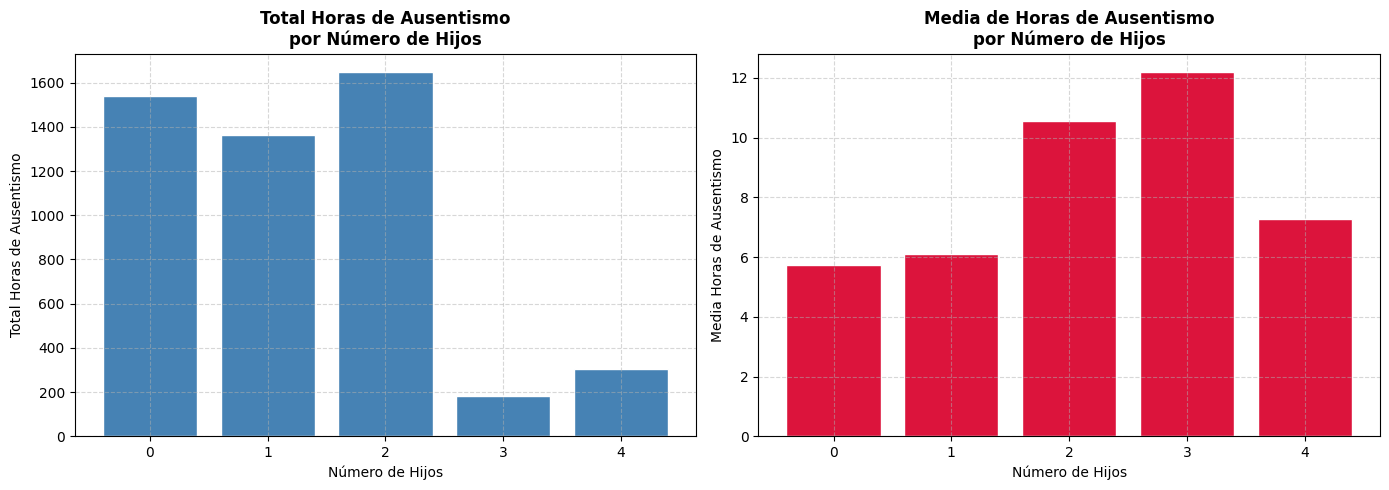

In [27]:
# Ausentismo por número de hijos
ausentismo_hijos = RRHH.groupby('Son')['Absenteeism_hours'].agg(['sum', 'mean', 'count'])
ausentismo_hijos.columns = ['Total Horas', 'Media Horas', 'Num Ausencias']
print(ausentismo_hijos)

# Ver distribución de hijos
print("\nDistribución por número de hijos:")
print(RRHH['Son'].value_counts().sort_index())

# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Total horas
ax1.bar(ausentismo_hijos.index.astype(str), ausentismo_hijos['Total Horas'],
        color='steelblue', edgecolor='white')
ax1.set_title('Total Horas de Ausentismo\npor Número de Hijos', fontsize=12, fontweight='bold')
ax1.set_xlabel('Número de Hijos')
ax1.set_ylabel('Total Horas de Ausentismo')
ax1.grid(True, linestyle='--', alpha=0.5)

# Media de horas
ax2.bar(ausentismo_hijos.index.astype(str), ausentismo_hijos['Media Horas'],
        color='crimson', edgecolor='white')
ax2.set_title('Media de Horas de Ausentismo\npor Número de Hijos', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Hijos')
ax2.set_ylabel('Media Horas de Ausentismo')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Análisis del Ausentismo por Carga Familiar:
* Tendencia en la Duración Media: Existe una correlación positiva clara entre el número de hijos y la duración de las ausencias. A mayor carga familiar, las bajas tienden a ser más prolongadas.
* Datos Clave de Duración (Gráfico Rojo):
Sin hijos: Promedio de 5,7 horas por baja.
1 hijo: El promedio sube ligeramente a unas 6 horas.
2 hijos: El impacto aumenta significativamente hasta las 10,6 horas.
3 hijos: Registran la media más alta con 12,2 horas por ausencia.
* Impacto Operativo Total (Gráfico Azul):
1 El grupo de empleados con 2 hijos es el que genera la mayor pérdida de tiempo para la empresa, superando las 1.600 horas totales.
2 Aunque los empleados con 3 hijos tienen las bajas más largas, su impacto total es menor debido a que hay menos trabajadores en esa categoría.
* Relevancia Estadística: El hallazgo es especialmente sólido para el grupo de 2 hijos, ya que cuenta con 156 registros, lo que lo hace estadísticamente relevante para el análisis.
* Recomendación: Se sugiere implementar programas de bienestar que incluyan apoyo a la conciliación familiar, dado que este es uno de los principales factores de riesgo identificados.

             sum      mean  count
No fumador  4692  7.196319    652
Fumador      351  6.500000     54


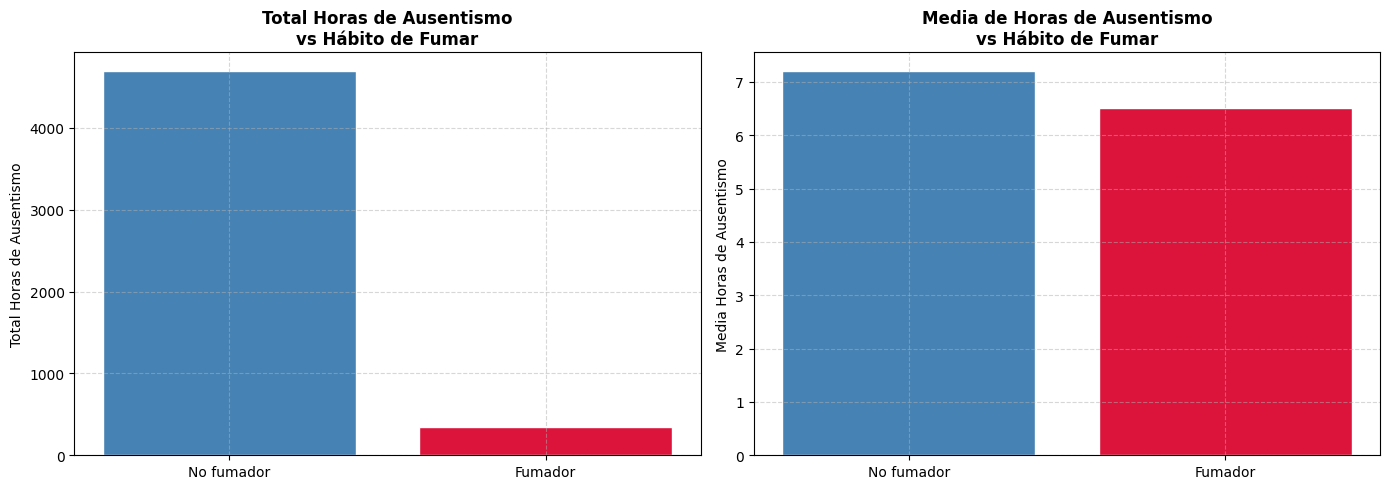

In [8]:
# Ausentismo por hábito de fumar
ausentismo_smoker = RRHH.groupby('Social_smoker')['Absenteeism_hours'].agg(['sum', 'mean', 'count'])
ausentismo_smoker.index = ['No fumador', 'Fumador']
print(ausentismo_smoker)

# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Total horas
ax1.bar(ausentismo_smoker.index, ausentismo_smoker['sum'],
        color=['steelblue', 'crimson'], edgecolor='white')
ax1.set_title('Total Horas de Ausentismo\nvs Hábito de Fumar', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Horas de Ausentismo')
ax1.grid(True, linestyle='--', alpha=0.5)

# Media de horas
ax2.bar(ausentismo_smoker.index, ausentismo_smoker['mean'],
        color=['steelblue', 'crimson'], edgecolor='white')
ax2.set_title('Media de Horas de Ausentismo\nvs Hábito de Fumar', fontsize=12, fontweight='bold')
ax2.set_ylabel('Media Horas de Ausentismo')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [45]:
print(RRHH['Social_smoker'].value_counts())

Social_smoker
False    652
True      54
Name: count, dtype: int64


Análisis del Ausentismo por Hábito de Fumar:
* Descarte como Factor de Riesgo: El hábito de fumar no muestra una relación clara con el ausentismo en esta organización. De hecho, los datos indican que ningún empleado clasificado dentro del grupo "crítico" es fumador.
* Comparativa de Duración Media (Gráfico Rojo): Contrario a lo que podría esperarse, los no fumadores presentan una media de horas de ausencia ligeramente superior (7,2 horas) a la de los fumadores (6,5 horas).
* Distribución del Impacto Total (Gráfico Azul): La gran mayoría de las horas perdidas por la empresa (más de 4.000 horas) son generadas por no fumadores, lo cual es lógico dado que este grupo representa a la gran mayoría de la plantilla.
* Limitación de los Datos: Se debe tener en cuenta que la muestra está muy desequilibrada, con 652 no fumadores frente a solo 54 fumadores, lo que dificulta extraer conclusiones definitivas de validez general.

             sum      mean  count
No bebedor  1870  6.091205    307
Bebedor     3173  7.952381    399

Distribución bebedores vs no bebedores:
Social_drinker
True     399
False    307
Name: count, dtype: int64


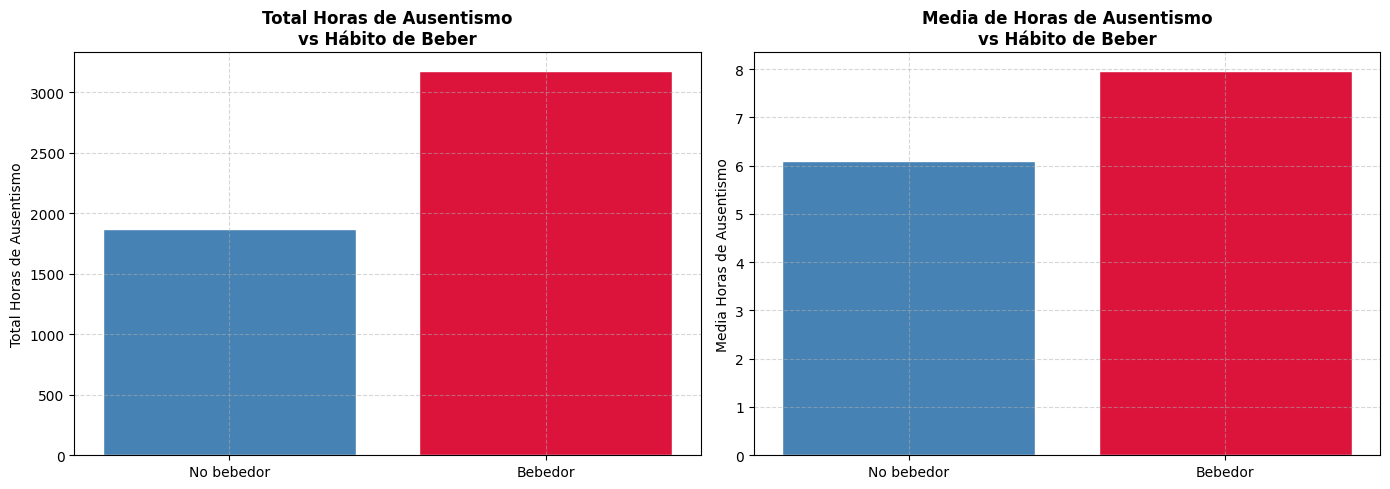

In [10]:
# Ausentismo por hábito de beber
ausentismo_drinker = RRHH.groupby('Social_drinker')['Absenteeism_hours'].agg(['sum', 'mean', 'count'])
ausentismo_drinker.index = ['No bebedor', 'Bebedor']
print(ausentismo_drinker)

# Ver distribución de bebedores vs no bebedores
print("\nDistribución bebedores vs no bebedores:")
print(RRHH['Social_drinker'].value_counts())

# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Total horas
ax1.bar(ausentismo_drinker.index, ausentismo_drinker['sum'],
        color=['steelblue', 'crimson'], edgecolor='white')
ax1.set_title('Total Horas de Ausentismo\nvs Hábito de Beber', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Horas de Ausentismo')
ax1.grid(True, linestyle='--', alpha=0.5)

# Media de horas
ax2.bar(ausentismo_drinker.index, ausentismo_drinker['mean'],
        color=['steelblue', 'crimson'], edgecolor='white')
ax2.set_title('Media de Horas de Ausentismo\nvs Hábito de Beber', fontsize=12, fontweight='bold')
ax2.set_ylabel('Media Horas de Ausentismo')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Análisis del Ausentismo por Consumo de Alcohol:
* Factor de Riesgo Crítico: El consumo social de alcohol se identifica como el factor de riesgo más consistente y sólido de todo el estudio.
* Impacto en la Duración Media (Gráfico Rojo): Los bebedores sociales presentan una media de 8 horas de ausencia por baja frente a las 6 horas de los no bebedores. Esto representa un incremento del 33% en la duración de las ausencias asociado a este hábito.
* Impacto Operativo Total (Gráfico Azul): El grupo de bebedores acumula un volumen de horas perdidas significativamente mayor, superando las 3.000 horas totales, frente a las menos de 2.000 horas del grupo no bebedor.
* Relación con Empleados Críticos: El factor diferenciador más significativo en el perfil de los empleados de alto riesgo es el consumo de alcohol: el 66,5% de los empleados críticos son bebedores sociales, frente al 56,5% de la media de la empresa.
* Fiabilidad de los Datos: Estos hallazgos se consideran estadísticamente fiables debido a una muestra equilibrada de 399 bebedores frente a 307 no bebedores.

# BLOQUE 5 - ANÁLISIS POR EMPLEADO

Top 10 empleados con más horas de baja:
    Total Horas  Media Horas  Num Ausencias
ID                                         
14          476    16.413793             29
11          450    11.250000             40
3           444     4.577320             97
28          343     4.635135             74
34          333     6.660000             50
36          311     9.147059             34
20          306     7.285714             42
9           262    32.750000              8
24          251     8.964286             28
15          251     6.972222             36


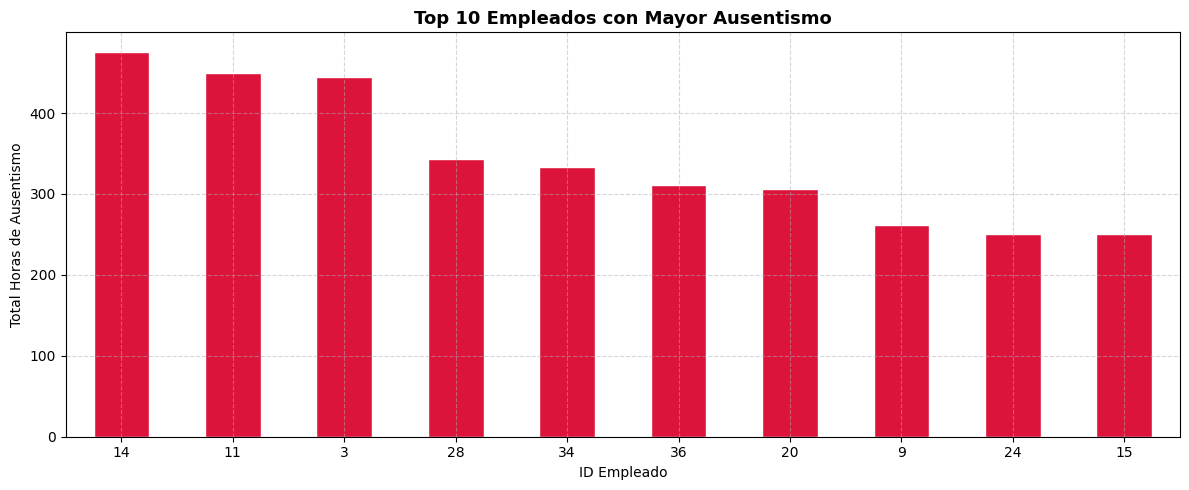

In [11]:
# Top empleados con más horas de baja acumuladas
ausentismo_empleado = RRHH.groupby('ID')['Absenteeism_hours'].agg(['sum', 'mean', 'count'])
ausentismo_empleado.columns = ['Total Horas', 'Media Horas', 'Num Ausencias']
ausentismo_empleado = ausentismo_empleado.sort_values('Total Horas', ascending=False)

print("Top 10 empleados con más horas de baja:")
print(ausentismo_empleado.head(10))

# Gráfico Top 10
plt.figure(figsize=(12, 5))
ausentismo_empleado['Total Horas'].head(10).plot(kind='bar', color='crimson', edgecolor='white')
plt.title('Top 10 Empleados con Mayor Ausentismo', fontsize=13, fontweight='bold')
plt.xlabel('ID Empleado')
plt.ylabel('Total Horas de Ausentismo')
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Análisis del Top 10 de Empleados Críticos:
* Liderazgo del Ranking: Los empleados ID 14, 11 y 3 encabezan la lista con 476, 450 y 444 horas acumuladas respectivamente.
* Perfiles de Ausentismo Contrastados:
- ID 3: Presenta un perfil de alta frecuencia, con 97 registros de corta duración.
- ID 9: Muestra un perfil de alta severidad, con solo 8 ausencias pero una media de 32,75 horas por baja.
- ID 14: Exhibe un perfil mixto de riesgo alto, combinando una frecuencia elevada (29 ausencias) con una duración media considerable (16,41 horas).
* Concentración del Problema: Estos 10 empleados representan una parte desproporcionada del ausentismo total de la empresa. De hecho, los IDs 3, 14, 11 y 28 son clasificados con un nivel de riesgo ALTO según el Índice de Magnitud.
* Factores Comunes: Se ha identificado que el 66,5% de estos empleados críticos son bebedores sociales, lo que refuerza el consumo de alcohol como el principal factor de riesgo individual.
* Acción Recomendada: Se debe priorizar una intervención inmediata con los tres primeros empleados del ranking (IDs 14, 11 y 3), ya que su ausencia acumulada representa el foco más crítico de pérdida de productividad actual en la empresa.

In [48]:
# Tasa de ausentismo
# Asumimos 8 horas por dia laboral y 261 dias laborales al año en Brasil
horas_laborales_totales = 8 * 261 * RRHH['ID'].nunique()

total_horas_ausentes = RRHH['Absenteeism_hours'].sum()

tasa_ausentismo = (total_horas_ausentes / horas_laborales_totales) * 100

print(f"Total horas ausentes: {total_horas_ausentes}")
print(f"Total horas laborales posibles: {horas_laborales_totales}")
print(f"Tasa de ausentismo global: {tasa_ausentismo:.2f}%")

# Tasa de ausentismo por empleado
tasa_por_empleado = RRHH.groupby('ID')['Absenteeism_hours'].sum() / (8 * 261) * 100
tasa_por_empleado = tasa_por_empleado.sort_values(ascending=False)

print("\nTasa de ausentismo por empleado (Top 10):")
print(tasa_por_empleado.head(10).round(2))

Total horas ausentes: 5043
Total horas laborales posibles: 75168
Tasa de ausentismo global: 6.71%

Tasa de ausentismo por empleado (Top 10):
ID
14    22.80
11    21.55
3     21.26
28    16.43
34    15.95
36    14.89
20    14.66
9     12.55
24    12.02
15    12.02
Name: Absenteeism_hours, dtype: float64


Frecuencia de ausencias por empleado:
Media de ausencias por empleado: 19.61
Máximo de ausencias: 97
Mínimo de ausencias: 1

Empleados con más de 20 ausencias: 13
ID
3     97
28    74
34    50
20    42
22    41
11    40
15    36
36    34
14    29
24    28
33    24
1     23
10    23
Name: Absenteeism_hours, dtype: int64


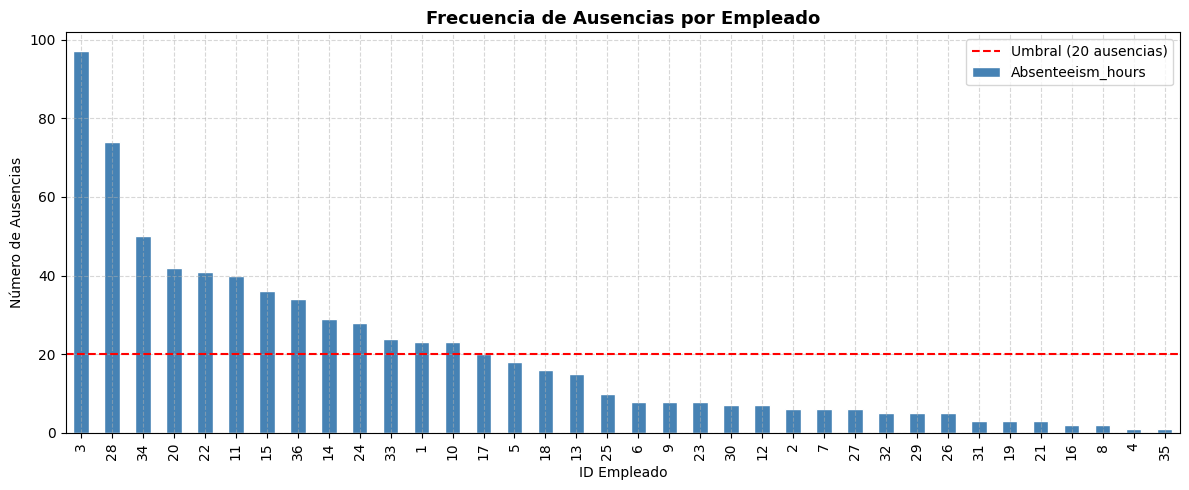

In [49]:
# KPI de frecuencia de ausencias por empleado
frecuencia_empleado = RRHH.groupby('ID')['Absenteeism_hours'].count()
frecuencia_empleado = frecuencia_empleado.sort_values(ascending=False)

print("Frecuencia de ausencias por empleado:")
print(f"Media de ausencias por empleado: {frecuencia_empleado.mean():.2f}")
print(f"Máximo de ausencias: {frecuencia_empleado.max()}")
print(f"Mínimo de ausencias: {frecuencia_empleado.min()}")

# Empleados que superan el umbral de 20 ausencias
umbral = 20
empleados_criticos = frecuencia_empleado[frecuencia_empleado > umbral]
print(f"\nEmpleados con más de {umbral} ausencias: {len(empleados_criticos)}")
print(empleados_criticos)

# Gráfico
plt.figure(figsize=(12, 5))
frecuencia_empleado.sort_values(ascending=False).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Frecuencia de Ausencias por Empleado', fontsize=13, fontweight='bold')
plt.xlabel('ID Empleado')
plt.ylabel('Número de Ausencias')
plt.axhline(y=umbral, color='red', linestyle='--', label=f'Umbral ({umbral} ausencias)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Análisis de la Frecuencia de Ausencias por Empleado:
* Líder Absoluto en Recurrencia: El empleado ID 3 destaca drásticamente sobre toda la plantilla con un total de 97 registros de ausencia. Aunque sus bajas son de corta duración (media de 4,58 horas), su patrón de faltas constantes lo convierte en el caso más crítico en términos de habitualidad.
* Casos de Alta Frecuencia: Otros empleados muestran una recurrencia muy superior a la media, destacando el ID 28 con 74 ausencias y los IDs 34, 20, 22 y 11, todos ellos superando los 40 registros.
* Umbral de Alerta: El gráfico establece un umbral de 20 ausencias (línea roja discontinua), el cual es superado por 14 empleados. Estar por encima de esta línea indica un comportamiento de ausentismo que afecta la continuidad operativa diaria de la empresa.
* Contraste con la Severidad: Este gráfico permite identificar que la frecuencia no siempre equivale a más horas totales. Por ejemplo, el ID 9 tiene una frecuencia muy baja (solo 8 ausencias), pero no aparece en los primeros puestos de este ranking a pesar de tener un impacto masivo en horas totales debido a la larga duración de sus bajas.
* Acción Recomendada: Se recomienda que Recursos Humanos analice específicamente los casos de los empleados ID 3 y ID 28. Dado que presentan una frecuencia de faltas extremadamente alta pero de corta duración, la intervención debe enfocarse en identificar posibles causas de micro-ausentismo o falta de motivación, diferenciándolos de los casos por enfermedad grave.

Duración media de baja por empleado:
Media global de duración por baja: 7.14 horas
Máxima duración media individual: 32.75 horas
Mínima duración media individual: 0.00 horas

Empleados con media de baja superior a 8 horas: 8
ID
9     32.75
26    16.60
14    16.41
13    12.20
11    11.25
36     9.15
6      9.00
24     8.96
Name: Absenteeism_hours, dtype: float64


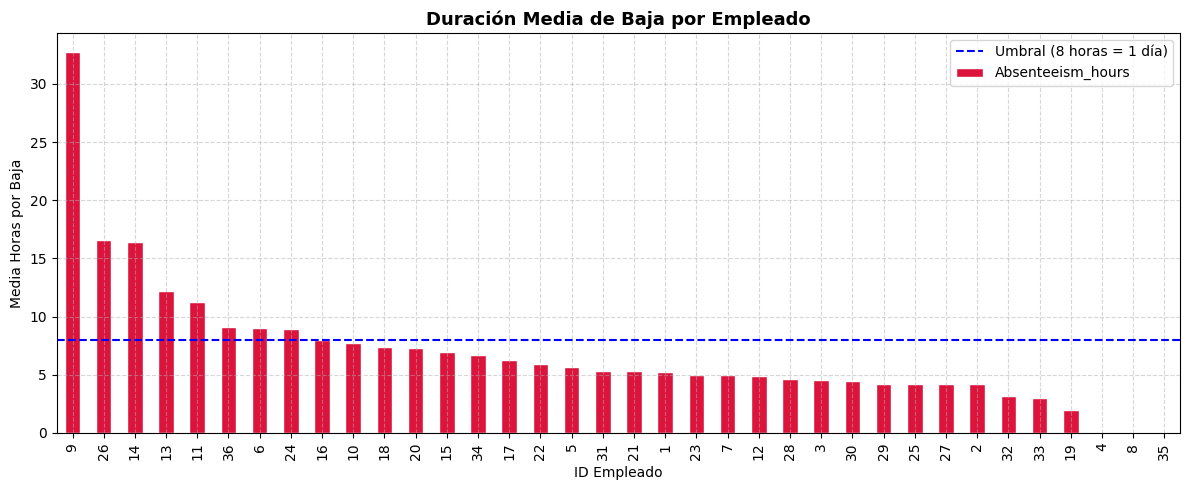

In [15]:
# KPI de duración media por baja
duracion_media = RRHH.groupby('ID')['Absenteeism_hours'].mean()
duracion_media = duracion_media.sort_values(ascending=False)

print("Duración media de baja por empleado:")
print(f"Media global de duración por baja: {RRHH['Absenteeism_hours'].mean():.2f} horas")
print(f"Máxima duración media individual: {duracion_media.max():.2f} horas")
print(f"Mínima duración media individual: {duracion_media.min():.2f} horas")

# Umbral de baja larga (más de 8 horas, es decir más de 1 día)
umbral_duracion = 8
empleados_bajas_largas = duracion_media[duracion_media > umbral_duracion]
print(f"\nEmpleados con media de baja superior a {umbral_duracion} horas: {len(empleados_bajas_largas)}")
print(empleados_bajas_largas.round(2))

# Gráfico
plt.figure(figsize=(12, 5))
duracion_media.sort_values(ascending=False).plot(kind='bar', color='crimson', edgecolor='white')
plt.title('Duración Media de Baja por Empleado', fontsize=13, fontweight='bold')
plt.xlabel('ID Empleado')
plt.ylabel('Media Horas por Baja')
plt.axhline(y=umbral_duracion, color='blue', linestyle='--', label=f'Umbral ({umbral_duracion} horas = 1 día)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Índice Global de Magnitud de Ausentismo por Empleado:
    Tasa_ausentismo  Frecuencia_ausencias  Duracion_media  Indice_magnitud
ID                                                                        
3             21.26                    97            4.58             0.79
14            22.80                    29           16.41             0.69
11            21.55                    40           11.25             0.67
28            16.43                    74            4.64             0.62
34            15.95                    50            6.66             0.55
9             12.55                     8           32.75             0.50
20            14.66                    42            7.29             0.50
36            14.89                    34            9.15             0.49
15            12.02                    36            6.97             0.42
22            11.59                    41            5.90             0.42


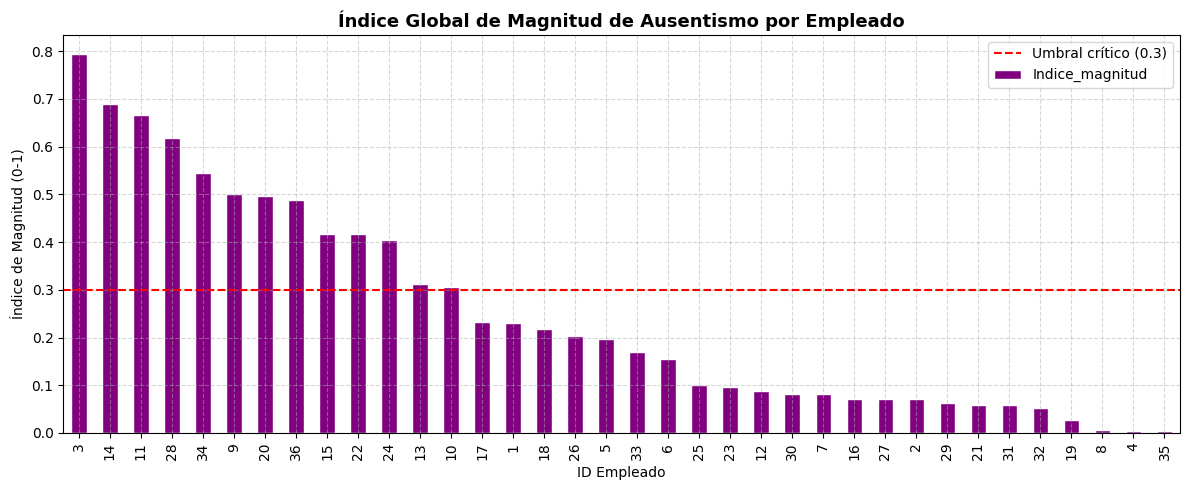

In [16]:
# Combinar los tres KPIs en un índice global de magnitud
import pandas as pd

# KPI 1: Tasa de ausentismo por empleado
tasa_empleado = RRHH.groupby('ID')['Absenteeism_hours'].sum() / (8 * 261) * 100

# KPI 2: Frecuencia de ausencias por empleado
frecuencia_empleado = RRHH.groupby('ID')['Absenteeism_hours'].count()

# KPI 3: Duración media por baja
duracion_media = RRHH.groupby('ID')['Absenteeism_hours'].mean()

# Combinar en un dataframe
indice = pd.DataFrame({
    'Tasa_ausentismo': tasa_empleado,
    'Frecuencia_ausencias': frecuencia_empleado,
    'Duracion_media': duracion_media
})

# Normalizar cada KPI entre 0 y 1
indice['Tasa_norm'] = indice['Tasa_ausentismo'] / indice['Tasa_ausentismo'].max()
indice['Frecuencia_norm'] = indice['Frecuencia_ausencias'] / indice['Frecuencia_ausencias'].max()
indice['Duracion_norm'] = indice['Duracion_media'] / indice['Duracion_media'].max()

# Calcular índice global ponderado
indice['Indice_magnitud'] = (
    indice['Tasa_norm'] * 0.5 +
    indice['Frecuencia_norm'] * 0.3 +
    indice['Duracion_norm'] * 0.2
)

indice = indice.sort_values('Indice_magnitud', ascending=False)

print("Índice Global de Magnitud de Ausentismo por Empleado:")
print(indice[['Tasa_ausentismo', 'Frecuencia_ausencias', 'Duracion_media', 'Indice_magnitud']].round(2).head(10))

# Gráfico
plt.figure(figsize=(12, 5))
indice['Indice_magnitud'].sort_values(ascending=False).plot(kind='bar', color='purple', edgecolor='white')
plt.title('Índice Global de Magnitud de Ausentismo por Empleado', fontsize=13, fontweight='bold')
plt.xlabel('ID Empleado')
plt.ylabel('Índice de Magnitud (0-1)')
plt.axhline(y=0.3, color='red', linestyle='--', label='Umbral crítico (0.3)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# BLOQUE 6 - CARGA LABORAL

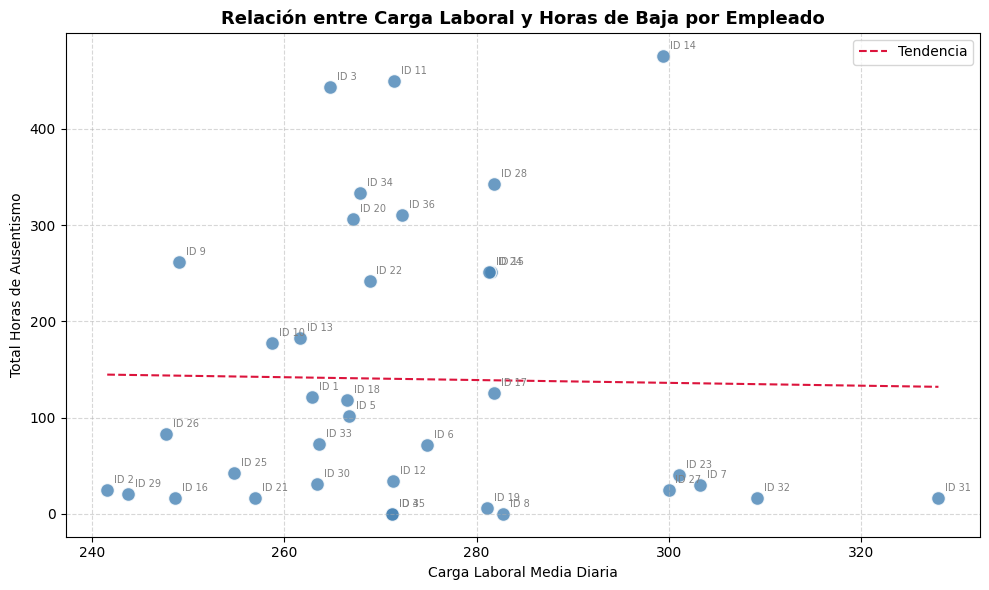

Correlación entre carga laboral y horas de baja: -0.019


In [28]:
# Scatterplot carga laboral vs horas de baja por empleado
carga_baja = RRHH.groupby('ID').agg(
    Carga_media=('Work_load_Average_day', 'mean'),
    Total_horas=('Absenteeism_hours', 'sum')
).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(carga_baja['Carga_media'], carga_baja['Total_horas'], 
            color='steelblue', edgecolor='white', s=100, alpha=0.8)

# Añadir etiqueta con ID de cada empleado
for i, row in carga_baja.iterrows():
    plt.annotate(f"ID {int(row['ID'])}", 
                 (row['Carga_media'], row['Total_horas']),
                 textcoords="offset points", xytext=(5, 5), fontsize=7, color='gray')

# Línea de tendencia
import numpy as np
z = np.polyfit(carga_baja['Carga_media'], carga_baja['Total_horas'], 1)
p = np.poly1d(z)
x_line = np.linspace(carga_baja['Carga_media'].min(), carga_baja['Carga_media'].max(), 100)
plt.plot(x_line, p(x_line), color='crimson', linestyle='--', linewidth=1.5, label='Tendencia')

plt.title('Relación entre Carga Laboral y Horas de Baja por Empleado', fontsize=13, fontweight='bold')
plt.xlabel('Carga Laboral Media Diaria')
plt.ylabel('Total Horas de Ausentismo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Correlación
correlacion = carga_baja['Carga_media'].corr(carga_baja['Total_horas'])
print(f"Correlación entre carga laboral y horas de baja: {correlacion:.3f}")

             Media Horas  Total Horas  Num Registros
Rango_carga                                         
Carga Baja      7.059561         2252            319
Carga Media     6.644068         1960            295
Carga Alta      9.032609          831             92


C:\Users\nuez_\AppData\Local\Temp\ipykernel_27492\484423529.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ausentismo_carga = RRHH.groupby('Rango_carga')['Absenteeism_hours'].agg(['mean', 'sum', 'count'])


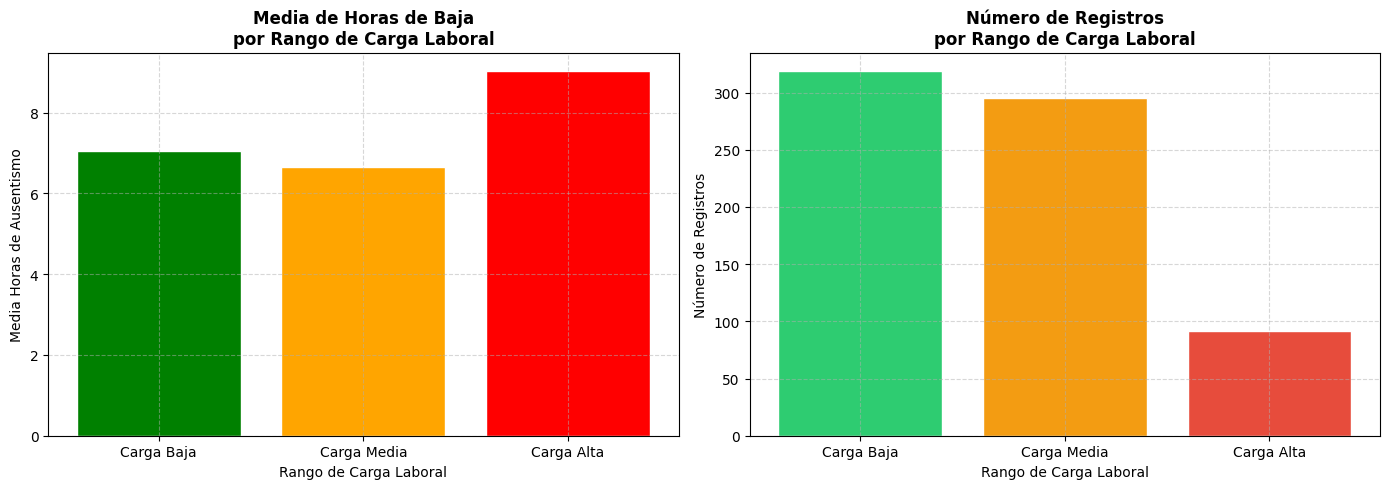

In [32]:
# Opción 3: Agrupar carga laboral en rangos y comparar horas de baja
import pandas as pd
import numpy as np

# Crear rangos de carga laboral
RRHH['Rango_carga'] = pd.cut(RRHH['Work_load_Average_day'], 
                              bins=3, 
                              labels=['Carga Baja', 'Carga Media', 'Carga Alta'])

# Calcular media de horas de baja por rango
ausentismo_carga = RRHH.groupby('Rango_carga')['Absenteeism_hours'].agg(['mean', 'sum', 'count'])
ausentismo_carga.columns = ['Media Horas', 'Total Horas', 'Num Registros']
print(ausentismo_carga)

# Gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Media de horas por rango
ax1.bar(ausentismo_carga.index, ausentismo_carga['Media Horas'],
        color=['Green', 'Orange', 'Red'], edgecolor='white')
ax1.set_title('Media de Horas de Baja\npor Rango de Carga Laboral', fontsize=12, fontweight='bold')
ax1.set_xlabel('Rango de Carga Laboral')
ax1.set_ylabel('Media Horas de Ausentismo')
ax1.grid(True, linestyle='--', alpha=0.5)

# Número de registros por rango
ax2.bar(ausentismo_carga.index, ausentismo_carga['Num Registros'],
        color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
ax2.set_title('Número de Registros\npor Rango de Carga Laboral', fontsize=12, fontweight='bold')
ax2.set_xlabel('Rango de Carga Laboral')
ax2.set_ylabel('Número de Registros')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# BLOQUE 7 - PERFIL DE RIESGO

                      Empleado Crítico  Media Empresa
Edad media                       35.82          36.48
Hijos medios                      1.03           1.06
% Bebedores                      66.54          56.52
% Fumadores                       0.00           7.65
Carga laboral media             272.43         272.09
Distancia media (km)             31.23          29.30
IMC medio                        26.35          26.64
Media horas baja                  7.79           7.14


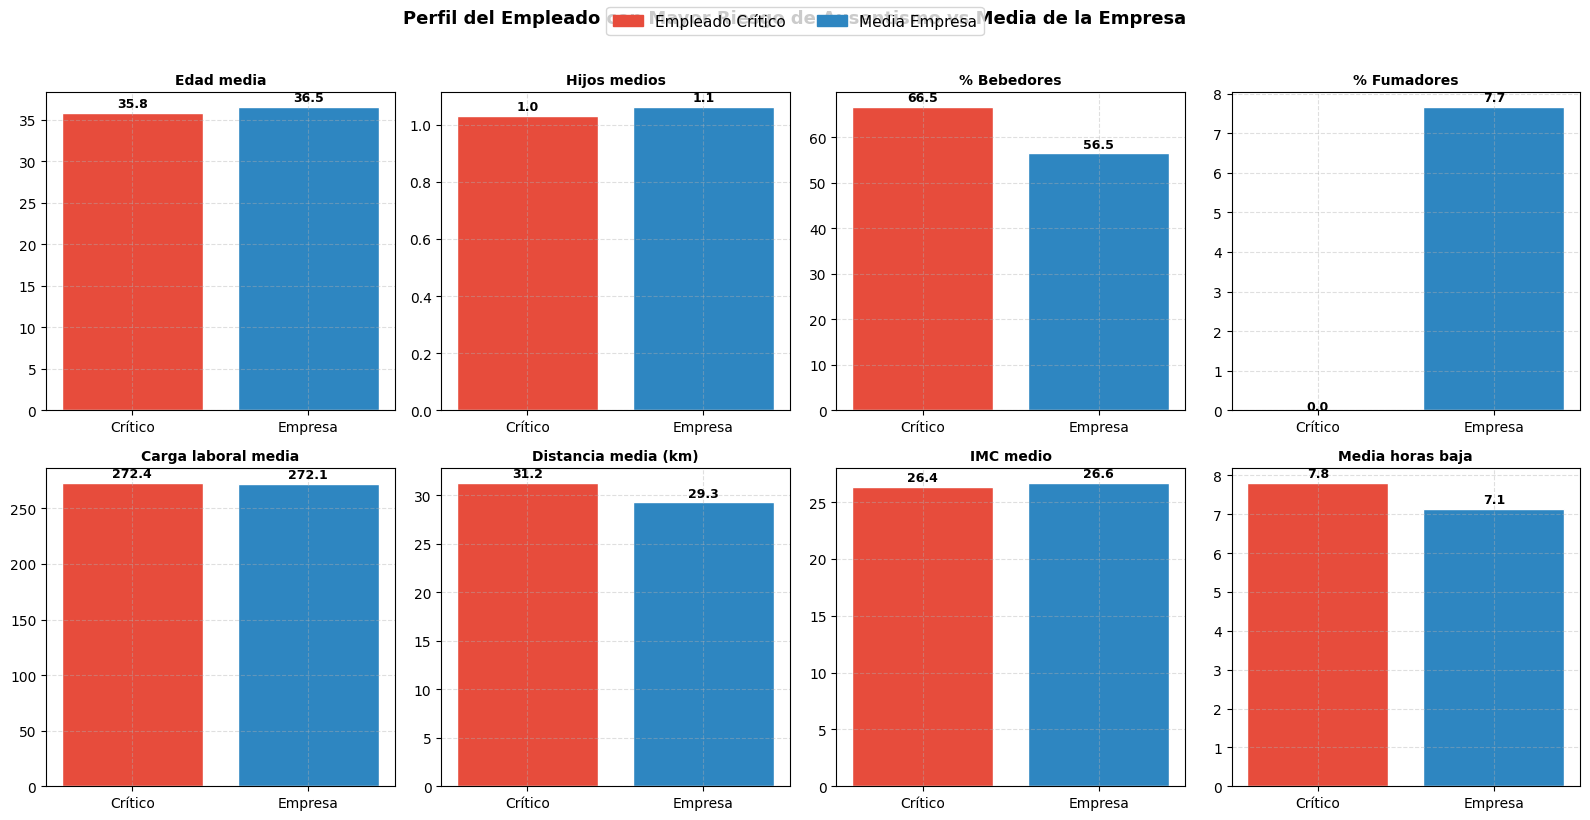

In [ ]:
# Perfil del empleado ausente recurrente
# Seleccionamos empleados que superan el umbral crítico del índice de magnitud
empleados_criticos = indice[indice['Indice_magnitud'] > 0.3].index.tolist()

perfil = RRHH[RRHH['ID'].isin(empleados_criticos)].agg({
    'Age': 'mean',
    'Son': 'mean',
    'Social_drinker': lambda x: (x == True).mean() * 100,
    'Social_smoker': lambda x: (x == True).mean() * 100,
    'Work_load_Average_day': 'mean',
    'Distance_Residence_Work': 'mean',
    'Body_mass_index': 'mean',
    'Absenteeism_hours': 'mean'
}).round(2)

perfil_total = RRHH.agg({
    'Age': 'mean',
    'Son': 'mean',
    'Social_drinker': lambda x: (x == True).mean() * 100,
    'Social_smoker': lambda x: (x == True).mean() * 100,
    'Work_load_Average_day': 'mean',
    'Distance_Residence_Work': 'mean',
    'Body_mass_index': 'mean',
    'Absenteeism_hours': 'mean'
}).round(2)

# Comparativa
comparativa = pd.DataFrame({
    'Empleado Crítico': perfil,
    'Media Empresa': perfil_total
})
comparativa.index = ['Edad media', 'Hijos medios', '% Bebedores', '% Fumadores', 
                     'Carga laboral media', 'Distancia media (km)', 'IMC medio', 'Media horas baja']
print(comparativa)

# Gráfico radar
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

variables = ['Edad media', 'Hijos medios', '% Bebedores', '% Fumadores',
             'Carga laboral media', 'Distancia media (km)', 'IMC medio', 'Media horas baja']
colores_critico ="#e74c3c"
colores_empresa ='#2e86c1'

for i, var in enumerate(variables):
    val_critico = comparativa.loc[var, 'Empleado Crítico']
    val_empresa = comparativa.loc[var, 'Media Empresa']
    
    axes[i].bar(['Crítico', 'Empresa'], [val_critico, val_empresa],
                color=[colores_critico, colores_empresa], edgecolor='white')
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.4)
    for j, v in enumerate([val_critico, val_empresa]):
        axes[i].text(j, v + v*0.02, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

patch1 = mpatches.Patch(color=colores_critico, label='Empleado Crítico')
patch2 = mpatches.Patch(color=colores_empresa, label='Media Empresa')
fig.legend(handles=[patch1, patch2], loc='upper center', ncol=2, fontsize=11)
fig.suptitle('Perfil del Empleado con Mayor Riesgo de Ausentismo vs Media de la Empresa', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [42]:
# Tabla resumen empleados críticos con su perfil completo
empleados_criticos_perfil = RRHH[RRHH['ID'].isin(empleados_criticos)].groupby('ID').agg(
    Total_horas=('Absenteeism_hours', 'sum'),
    Num_ausencias=('Absenteeism_hours', 'count'),
    Media_horas=('Absenteeism_hours', 'mean'),
    Edad=('Age', 'mean'),
    Hijos=('Son', 'mean'),
    Bebedor=('Social_drinker', 'first'),
    Fumador=('Social_smoker', 'first'),
    Distancia=('Distance_Residence_Work', 'mean')
).round(2)

# Añadir el índice de magnitud
empleados_criticos_perfil['Indice_magnitud'] = indice.loc[empleados_criticos_perfil.index, 'Indice_magnitud'].round(2)

# Ordenar por índice de magnitud
empleados_criticos_perfil = empleados_criticos_perfil.sort_values('Indice_magnitud', ascending=False)

print("EMPLEADOS DE MAYOR RIESGO:")
print(empleados_criticos_perfil)

EMPLEADOS DE MAYOR RIESGO:
    Total_horas  Num_ausencias  Media_horas  Edad  Hijos  Bebedor  Fumador  \
ID                                                                           
3           444             97         4.58  38.0    0.0     True    False   
14          476             29        16.41  34.0    2.0     True    False   
11          450             40        11.25  33.0    2.0     True    False   
28          343             74         4.64  28.0    1.0    False    False   
34          333             50         6.66  37.0    0.0    False    False   
9           262              8        32.75  58.0    2.0    False    False   
20          306             42         7.29  36.0    4.0     True    False   
36          311             34         9.15  50.0    1.0     True    False   
15          251             36         6.97  40.0    1.0     True    False   
22          242             41         5.90  30.0    0.0    False    False   
24          251             28       

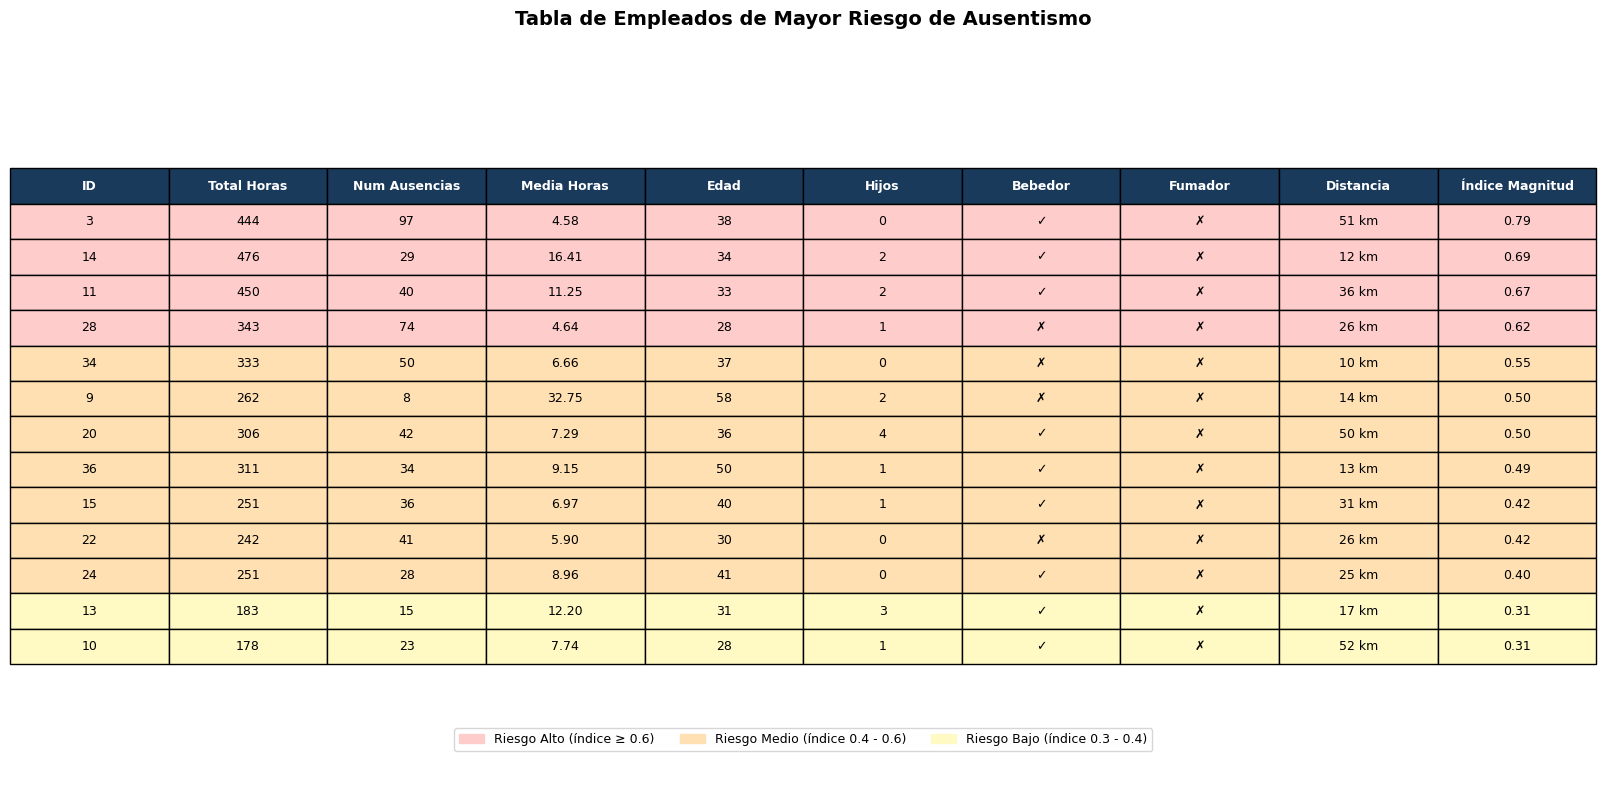

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Tabla visual con colores semáforo según índice de magnitud
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')

# Datos para la tabla
columnas = ['ID', 'Total Horas', 'Num Ausencias', 'Media Horas', 
            'Edad', 'Hijos', 'Bebedor', 'Fumador', 'Distancia', 'Índice Magnitud']

filas = []
colores_filas = []

for idx, row in empleados_criticos_perfil.iterrows():
    fila = [
        str(int(idx)),
        str(int(row['Total_horas'])),
        str(int(row['Num_ausencias'])),
        f"{row['Media_horas']:.2f}",
        str(int(row['Edad'])),
        str(int(row['Hijos'])),
        '✓' if row['Bebedor'] == True else '✗',
        '✓' if row['Fumador'] == True else '✗',
        f"{row['Distancia']:.0f} km",
        f"{row['Indice_magnitud']:.2f}"
    ]
    filas.append(fila)
    
    # Color según índice de magnitud
    if row['Indice_magnitud'] >= 0.6:
        colores_filas.append(['#ffcccc'] * len(columnas))  # Rojo claro - crítico alto
    elif row['Indice_magnitud'] >= 0.4:
        colores_filas.append(['#ffe0b2'] * len(columnas))  # Naranja claro - crítico medio
    else:
        colores_filas.append(['#fff9c4'] * len(columnas))  # Amarillo claro - crítico bajo

tabla = ax.table(
    cellText=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center',
    cellColours=colores_filas
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.2, 1.8)

# Color cabecera
for j in range(len(columnas)):
    tabla[0, j].set_facecolor('#1a3a5c')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

# Leyenda semáforo
patch_rojo = mpatches.Patch(color'#ffcccc', label='Riesgo Alto (índice ≥ 0.6)')
patch_naranja = mpatches.Patch(color'#ffe0b2', label='Riesgo Medio (índice 0.4 - 0.6)')
patch_amarillo = mpatches.Patch(color'#fff9c4', label='Riesgo Bajo (índice 0.3 - 0.4)')
ax.legend(handles=[patch_rojo, patch_naranja, patch_amarillo], 
          loc='upper center', bbox_to_anchor=(0.5, 0.08), ncol=3, fontsize=9)

plt.title('Tabla de Empleados de Mayor Riesgo de Ausentismo', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

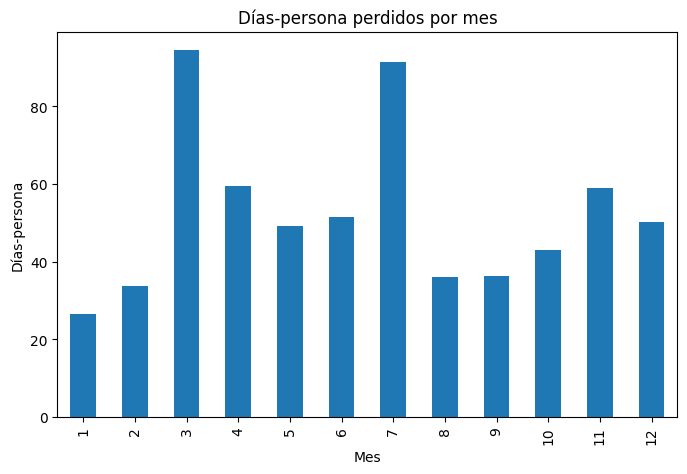

In [54]:
# 1. Filtrar el mes 0 antes de cualquier cálculo
# Esto elimina los registros inconsistentes que aparecen en el heatmap [3]
RRHH = RRHH[RRHH["Month_absence"] != 0]

# 2. Horas por mes (ahora solo con meses del 1 al 12)
absentismo_mes = RRHH.groupby("Month_absence")["Absenteeism_hours"].sum().sort_index()

# 3. Conversión a días-persona (jornada 8h)
dias_mes = absentismo_mes / 8

# 4. Visualización
plt.figure(figsize=(8,5))
dias_mes.plot(kind="bar")
plt.title("Días-persona perdidos por mes")
plt.xlabel("Mes")
plt.ylabel("Días-persona")
plt.show()

Mes crítico: 3
Mes valle: 1
Diferencia porcentual: 256.13 %


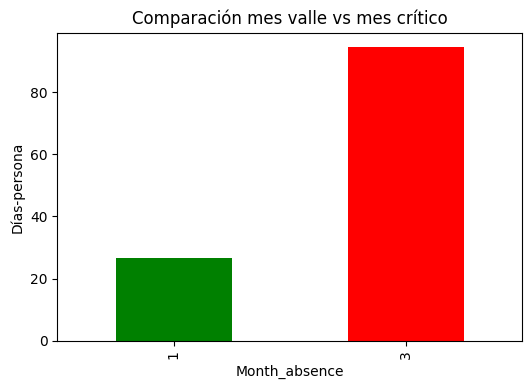

In [55]:
mes_max = dias_mes.idxmax()
mes_min = dias_mes.idxmin()
valor_max = dias_mes.max()
valor_min = dias_mes.min()
diferencia_pct = ((valor_max - valor_min) / valor_min) * 100
print("Mes crítico:", mes_max)
print("Mes valle:", mes_min)
print("Diferencia porcentual:", round(diferencia_pct,2), "%")
#Si quieres hacerlo visualmente claro:
plt.figure(figsize=(6,4))
dias_mes.loc[[mes_min, mes_max]].plot(kind="bar", color=["green","red"])
plt.title("Comparación mes valle vs mes crítico")
plt.ylabel("Días-persona")
plt.show()

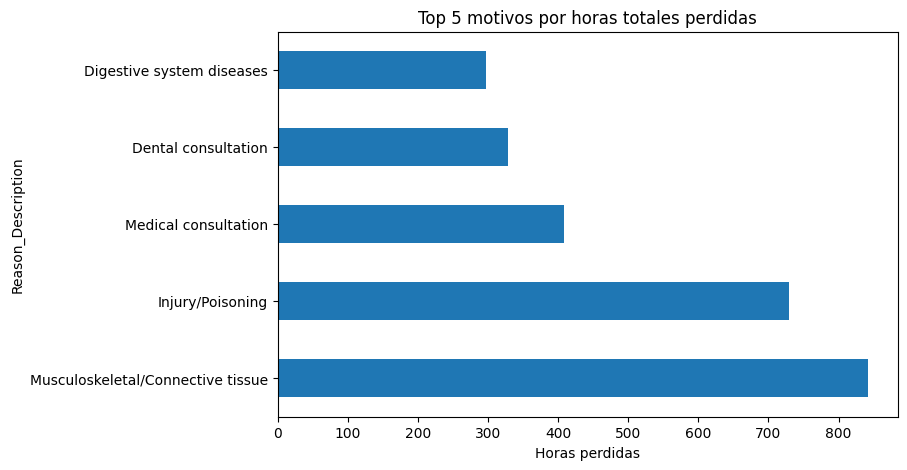

In [56]:
motivos_horas = RRHH.groupby("Reason_Description")["Absenteeism_hours"].sum().sort_values(ascending=False)
top5 = motivos_horas.head(5)
plt.figure(figsize=(8,5))
top5.plot(kind="barh")
plt.title("Top 5 motivos por horas totales perdidas")
plt.xlabel("Horas perdidas")
plt.show()